# Chest X-Ray Classification using Deep Learning

**Goal:** Build a model that can look at a chest X-ray and decide:
- Normal lungs
- Bacterial Pneumonia
- Viral Pneumonia

**Notebook Steps:**
1. Install and Import Libraries
2. Reorganize Dataset into 3 Class Folders (fixes the shape error!)
3. Data Loading and Understanding
4. Image Preprocessing
5. Build and Train the CNN Model
6. Evaluate the Model
7. Visualizations and Final Analysis

## Install Required Libraries

In [1]:
!pip install tensorflow matplotlib seaborn scikit-learn numpy opencv-python-headless Pillow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 1: Import All Libraries

In [2]:

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
import cv2

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


All libraries imported successfully!
TensorFlow version: 2.21.0


## Step 2: Reorganize Dataset into 3 Classes

### Why this step is needed (the root cause of your error):

The Kaggle dataset folder looks like this by default:
```
chest_xray/
  train/
    NORMAL/      <- normal images
    PNEUMONIA/   <- ALL pneumonia (bacteria + virus are MIXED in one folder)
```

When TensorFlow reads folders, it counts subfolders as classes.
2 subfolders = 2 classes. But our model was built for 3 classes.

### The fix:
We copy the images into a NEW folder with 3 subfolders:
```
chest_xray_3class/
  train/
    NORMAL/
    BACTERIA/    <- images with 'bacteria' in filename
    VIRUS/       <- images with 'virus' in filename

In [3]:
# ---------------------------------------------------------------
# UPDATE THIS PATH to where your Kaggle dataset folder is saved
# ---------------------------------------------------------------
ORIGINAL_DIR = 'dataset/chest_xray'          # Original dataset
NEW_DIR      = 'dataset/chest_xray_3class'   # We will create this

SPLITS  = ['train', 'test', 'val']
CLASSES = ['NORMAL', 'BACTERIA', 'VIRUS']


def reorganize_dataset(original_dir, new_dir):
    """
    Copies images from the original 2-class structure
    into a new 3-class structure (NORMAL, BACTERIA, VIRUS).
    """
    if os.path.exists(new_dir):
        print(f'Reorganized dataset already exists at: {new_dir}')
        print('Skipping. Delete the folder to redo it.')
        return

    print('Reorganizing dataset into 3 classes...')
    total_copied = 0

    for split in SPLITS:
        src_split = os.path.join(original_dir, split)
        if not os.path.exists(src_split):
            print(f'  Skipping {split} - folder not found')
            continue

        # Create destination class folders
        for cls in CLASSES:
            os.makedirs(os.path.join(new_dir, split, cls), exist_ok=True)

        for label_folder in os.listdir(src_split):
            label_path = os.path.join(src_split, label_folder)
            if not os.path.isdir(label_path):
                continue

            for filename in os.listdir(label_path):
                src = os.path.join(label_path, filename)

                # Decide which of the 3 classes this image belongs to
                if label_folder.upper() == 'NORMAL':
                    dest_class = 'NORMAL'
                elif 'bacteria' in filename.lower():
                    dest_class = 'BACTERIA'
                elif 'virus' in filename.lower():
                    dest_class = 'VIRUS'
                else:
                    continue  # Skip any unrecognized file

                dest = os.path.join(new_dir, split, dest_class, filename)
                shutil.copy2(src, dest)
                total_copied += 1

        print(f'  Done: {split} split')

    print(f'\nFinished! Copied {total_copied} images total.')


reorganize_dataset(ORIGINAL_DIR, NEW_DIR)

# Set the new paths we will use from now on
TRAIN_DIR = os.path.join(NEW_DIR, 'train')
TEST_DIR  = os.path.join(NEW_DIR, 'test')

print(f'\nTrain folder: {TRAIN_DIR}')
print(f'Test folder : {TEST_DIR}')

Reorganizing dataset into 3 classes...
  Done: train split
  Done: test split
  Skipping val - folder not found

Finished! Copied 5856 images total.

Train folder: dataset/chest_xray_3class\train
Test folder : dataset/chest_xray_3class\test


## Step 3: Data Loading and Understanding (5 Marks)

In [4]:
# Count images in each class folder

def count_images(folder):
    counts = {}
    for cls in sorted(os.listdir(folder)):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print('Training Set:')
for cls, n in train_counts.items():
    print(f'  {cls:12s}: {n} images')

print('\nTest Set:')
for cls, n in test_counts.items():
    print(f'  {cls:12s}: {n} images')

print(f'\nTotal: {sum(train_counts.values()) + sum(test_counts.values())} images')

Training Set:
  BACTERIA    : 2538 images
  NORMAL      : 1349 images
  VIRUS       : 1345 images

Test Set:
  BACTERIA    : 242 images
  NORMAL      : 234 images
  VIRUS       : 148 images

Total: 5856 images


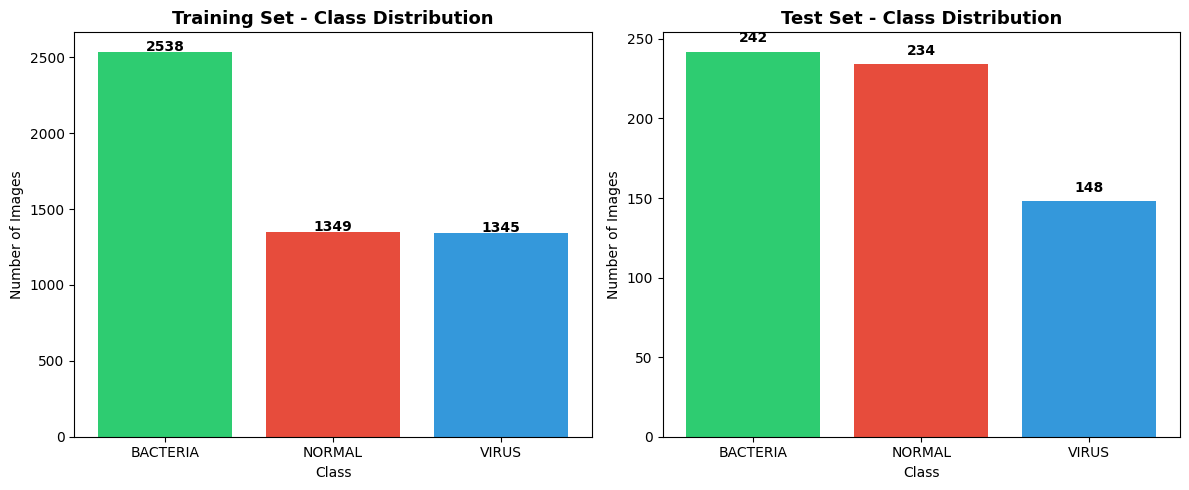

In [5]:
# Bar chart: class distribution

colors = ['#2ecc71', '#e74c3c', '#3498db']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (counts, title) in zip(axes, [
    (train_counts, 'Training Set - Class Distribution'),
    (test_counts,  'Test Set - Class Distribution')
]):
    bars = ax.bar(counts.keys(), counts.values(), color=colors)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Number of Images')
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 6, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

##  This is class imbalance. We will fix it using class weights.

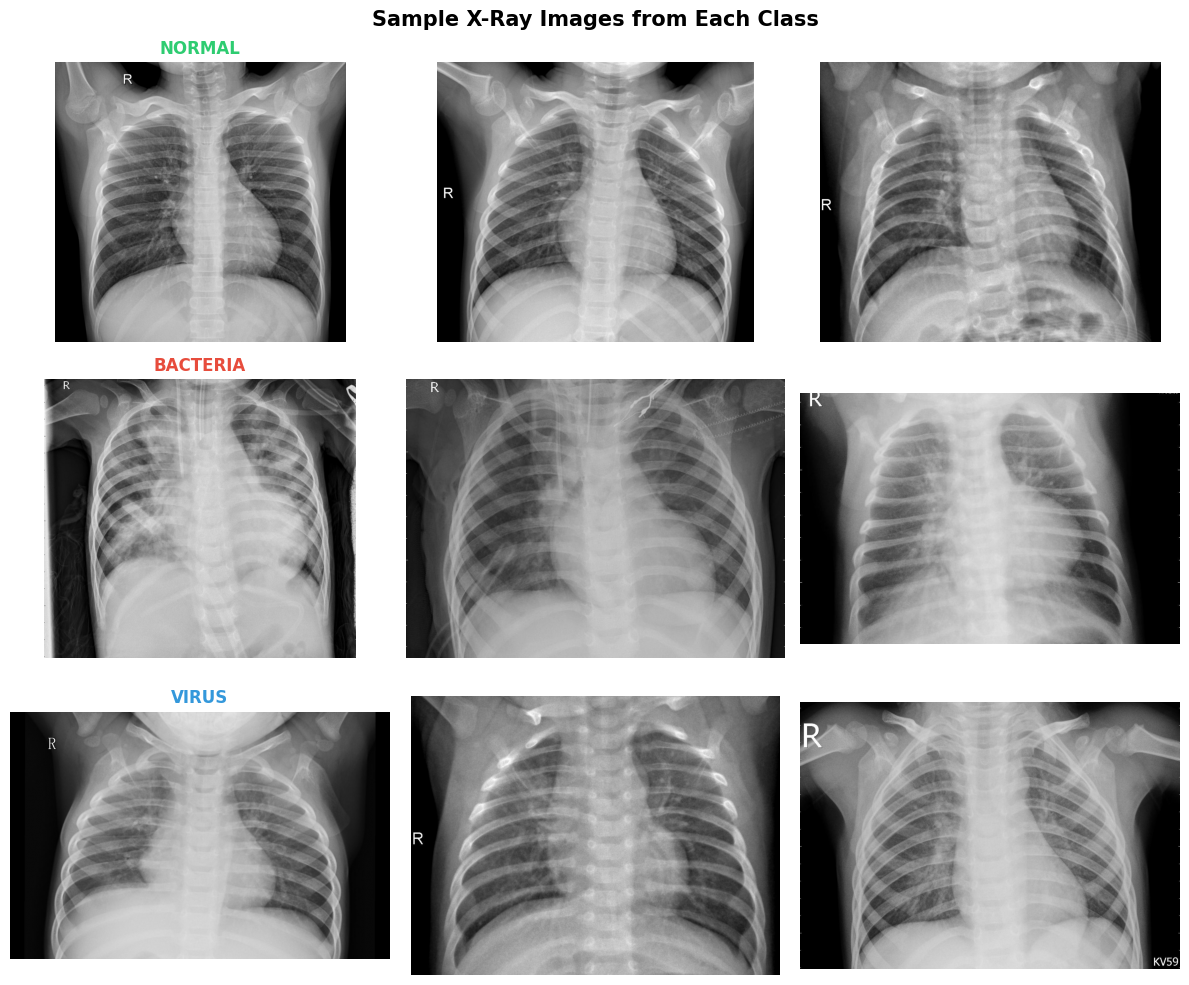

In [6]:
# Display sample images from each class

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle('Sample X-Ray Images from Each Class', fontsize=15, fontweight='bold')

class_colors = {'NORMAL': '#2ecc71', 'BACTERIA': '#e74c3c', 'VIRUS': '#3498db'}

for row_idx, cls in enumerate(CLASSES):
    cls_path     = os.path.join(TRAIN_DIR, cls)
    sample_files = os.listdir(cls_path)[:3]

    for col_idx, fname in enumerate(sample_files):
        img = Image.open(os.path.join(cls_path, fname)).convert('L')
        axes[row_idx][col_idx].imshow(img, cmap='gray')
        axes[row_idx][col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx][col_idx].set_title(
                cls, fontsize=12,
                color=class_colors[cls], fontweight='bold'
            )

plt.tight_layout()
plt.savefig('content/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Check image dimensions and formats

print('Image info from each class:\n')
for cls in CLASSES:
    cls_path    = os.path.join(TRAIN_DIR, cls)
    sample_file = os.listdir(cls_path)[0]
    img         = Image.open(os.path.join(cls_path, sample_file))
    print(f'  {cls}:')
    print(f'    Size : {img.size}  (width x height)')
    print(f'    Mode : {img.mode}  (L=grayscale, RGB=color)')
    print()

print('Note: Images have different sizes, so we will resize all to 224x224.')

Image info from each class:

  NORMAL:
    Size : (2572, 2476)  (width x height)
    Mode : L  (L=grayscale, RGB=color)

  BACTERIA:
    Size : (1152, 1032)  (width x height)
    Mode : L  (L=grayscale, RGB=color)

  VIRUS:
    Size : (1604, 1044)  (width x height)
    Mode : L  (L=grayscale, RGB=color)

Note: Images have different sizes, so we will resize all to 224x224.



## Step 4: Image Preprocessing

**What we do:**
 Resize all images to 224x224 pixels
 Normalize pixel values from 0-255 to 0-1 (makes training stable)
 Apply data augmentation to training images only
 Split into Training, Validation, and Test sets

**Data Augmentation** creates variations of training images (rotated, flipped, zoomed)

In [8]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 3   # This now matches our 3 folders: NORMAL, BACTERIA, VIRUS

# Training generator WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize: divide by 255
    rotation_range=15,       # Rotate randomly up to 15 degrees
    horizontal_flip=True,    # Randomly flip left to right
    zoom_range=0.1,          # Randomly zoom in or out by 10%
    width_shift_range=0.1,   # Slight horizontal shift
    height_shift_range=0.1,  # Slight vertical shift
    validation_split=0.2     # Reserve 20% of training data for validation
)

# Test generator WITHOUT augmentation
# We test on real unmodified images
test_datagen = ImageDataGenerator(rescale=1./255)

print('Data generators ready!')

Data generators ready!


In [9]:
# Load images from the 3-class folder structure
# flow_from_directory reads each subfolder as a class label automatically

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',  # Returns one-hot encoded labels like [1,0,0]
    subset='training',
    color_mode='rgb',
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    color_mode='rgb',
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,             # Keep original order for evaluation
    color_mode='rgb'
)

CLASS_NAMES = list(train_generator.class_indices.keys())
print(f'\nClass mapping : {train_generator.class_indices}')
print(f'Class names   : {CLASS_NAMES}')
print(f'\nTraining images  : {train_generator.samples}')
print(f'Validation images: {val_generator.samples}')
print(f'Test images      : {test_generator.samples}')

Found 4187 images belonging to 3 classes.
Found 1045 images belonging to 3 classes.
Found 624 images belonging to 3 classes.

Class mapping : {'BACTERIA': 0, 'NORMAL': 1, 'VIRUS': 2}
Class names   : ['BACTERIA', 'NORMAL', 'VIRUS']

Training images  : 4187
Validation images: 1045
Test images      : 624


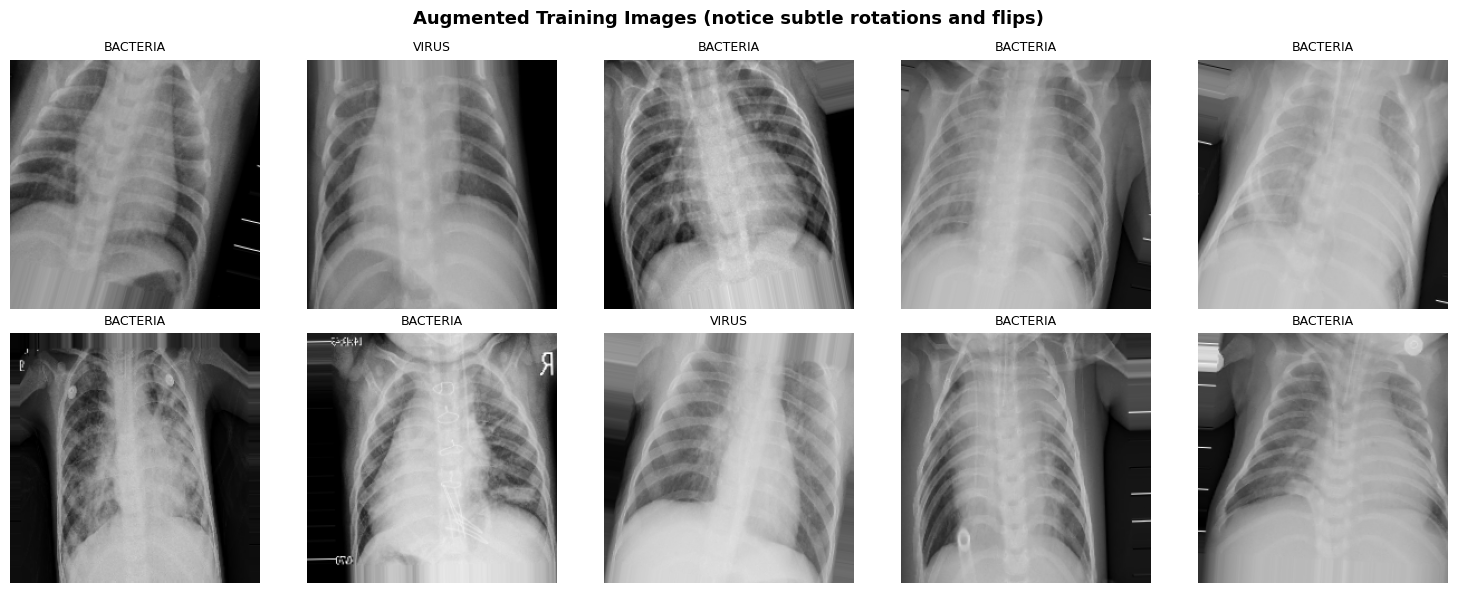

In [10]:
# Show a sample batch of augmented images

sample_imgs, sample_labels = next(train_generator)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Augmented Training Images (notice subtle rotations and flips)', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i])
    ax.set_title(CLASS_NAMES[np.argmax(sample_labels[i])], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('content/augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 5: Build the CNN Model

**Simple explanation of CNN layers:**
- **Conv2D** - scans the image with a small window to detect patterns (edges, textures)
- **BatchNormalization** - keeps numbers stable during training
- **MaxPooling2D** - shrinks the image, keeping only the strongest features
- **Dropout** - randomly ignores some connections to prevent the model from memorizing
- **Flatten** - converts the 2D image data into a 1D list of numbers
- **Dense** - regular neural network layer that makes the final classification
- **Softmax** - converts the output into 3 probabilities (one per class) that sum to 1.0

In [11]:
model = Sequential([

    # Block 1: Detect basic patterns like edges
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),   # Image shrinks: 224 -> 112
    Dropout(0.25),

    # Block 2: Detect medium patterns like shapes
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),   # 112 -> 56
    Dropout(0.25),

    # Block 3: Detect complex patterns like lung structures
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),   # 56 -> 28
    Dropout(0.25),

    # Convert 2D feature map to 1D list
    Flatten(),

    # Decision layers
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),

    # Output: 3 neurons for 3 classes (matches NUM_CLASSES = 3)
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      25,690,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 26,012,579 (99.23 MB)

 Trainable params: 26,011,619 (99.23 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
# Compute class weights to handle imbalance
# The model will be penalized more for mistakes on underrepresented classes

weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(weights_array))

print('Class Weights (higher weight = model pays more attention to that class):')
for idx, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:12s}: {weights_array[idx]:.3f}')

Class Weights (higher weight = model pays more attention to that class):
  BACTERIA    : 0.687
  NORMAL      : 1.292
  VIRUS       : 1.297


In [13]:
# Training callbacks

# Stop training automatically if the model stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,  # Revert to best version at the end
    verbose=1
)

# Slow down the learning rate if training gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print('Callbacks ready!')

Callbacks ready!


---
## Step 6: Train the Model

One **epoch** = the model looks at all training images once and updates itself.
We set a maximum of 30 epochs, but early stopping may stop it sooner.

Tip: Use Google Colab with GPU for much faster training.

In [15]:
EPOCHS = 15

print('Starting training...')
print(f'  Training images  : {train_generator.samples}')
print(f'  Validation images: {val_generator.samples}')
print(f'  Max epochs       : {EPOCHS}\n')

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict
)

print('\nTraining complete!')

Starting training...
  Training images  : 4187
  Validation images: 1045
  Max epochs       : 15

Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.5937 - loss: 0.8640 - val_accuracy: 0.4852 - val_loss: 3.8745 - learning_rate: 0.0010
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.6520 - loss: 0.6982 - val_accuracy: 0.4852 - val_loss: 2.3778 - learning_rate: 0.0010
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 235s 2s/step - accuracy: 0.6960 - loss: 0.6505 - val_accuracy: 0.2574 - val_loss: 2.1619 - learning_rate: 0.0010
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.7108 - loss: 0.6158 - val_accuracy: 0.6842 - val_loss: 0.7125 - learning_rate: 0.0010
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 233s 2s/step - accuracy: 0.7041 - loss: 0.6169 - val_accuracy: 0.5789 - val_loss: 1.4783 - learning_rate: 0.0010
Epoch 6/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.7225 - loss: 0.6004 - val_accuracy: 0.5321 - val_loss: 2.1387 - learni

---
## Step 7: Training Curves

- Accuracy going UP is good
- Loss going DOWN is good
- If training accuracy is much higher than validation accuracy, the model is overfitting (memorizing instead of learning)

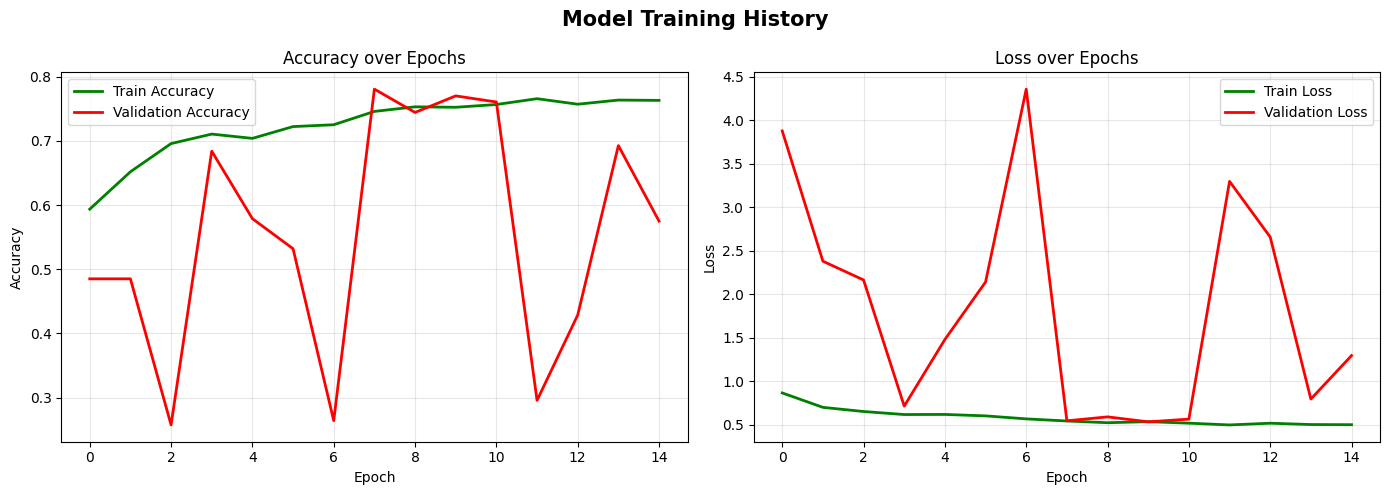

Best Validation Accuracy: 78.09%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Training History', fontsize=15, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='green', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red',   linewidth=2)
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss',      color='green', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='red',   linewidth=2)
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

best_val_acc = max(history.history['val_accuracy'])
print(f'Best Validation Accuracy: {best_val_acc*100:.2f}%')

---
## Step 8: Evaluate the Model

We test on images the model has NEVER seen before.

In [17]:
print('Evaluating on test data...')
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f'\nTest Accuracy : {test_accuracy*100:.2f}%')
print(f'Test Loss     : {test_loss:.4f}')

Evaluating on test data...
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 609ms/step - accuracy: 0.8494 - loss: 0.4960

Test Accuracy : 84.94%
Test Loss     : 0.4960


In [18]:
# Get predictions
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)  # Pick highest probability class
y_true       = test_generator.classes            # Actual labels

print(f'Predicted {len(y_pred)} images')
print(f'Classes  : {CLASS_NAMES}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 393ms/step 
Predicted 624 images
Classes  : ['BACTERIA', 'NORMAL', 'VIRUS']


In [20]:
# Classification report: precision, recall, F1-score

print('Classification Report:')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Classification Report:
              precision    recall  f1-score   support

    BACTERIA       0.84      0.90      0.87       242
      NORMAL       0.84      0.95      0.89       234
       VIRUS       0.92      0.59      0.72       148

    accuracy                           0.85       624
   macro avg       0.86      0.82      0.83       624
weighted avg       0.86      0.85      0.84       624



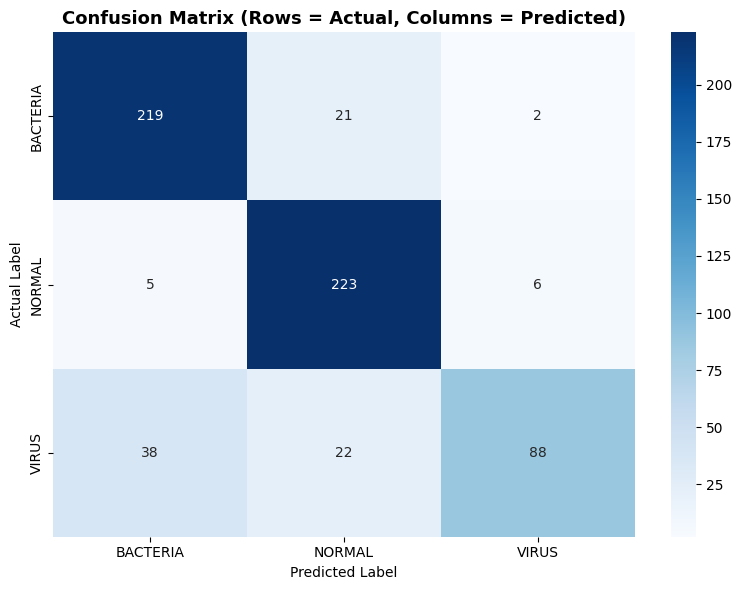

In [23]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title('Confusion Matrix (Rows = Actual, Columns = Predicted)', fontsize=13, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Diagonal = Correct predictions
## Off-diagonal = Mistakes (model confused one class for another)

In [24]:
# Class-wise analysis

print('Class-wise Performance:\n')
for i, cls in enumerate(CLASS_NAMES):
    correct = cm[i][i]
    total   = cm[i].sum()
    recall  = correct / total * 100
    print(f'  {cls}:')
    print(f'    Correctly identified: {correct}/{total} ({recall:.1f}%)')
    mistakes = {CLASS_NAMES[j]: int(cm[i][j])
                for j in range(len(CLASS_NAMES)) if j != i and cm[i][j] > 0}
    if mistakes:
        print(f'    Confused with      : {mistakes}')
    print()

print('Insight: BACTERIA vs VIRUS is typically the hardest pair to separate,')
print('because both cause similar cloudy/hazy patterns in chest X-rays.')

Class-wise Performance:

  BACTERIA:
    Correctly identified: 219/242 (90.5%)
    Confused with      : {'NORMAL': 21, 'VIRUS': 2}

  NORMAL:
    Correctly identified: 223/234 (95.3%)
    Confused with      : {'BACTERIA': 5, 'VIRUS': 6}

  VIRUS:
    Correctly identified: 88/148 (59.5%)
    Confused with      : {'BACTERIA': 38, 'NORMAL': 22}

Insight: BACTERIA vs VIRUS is typically the hardest pair to separate,
because both cause similar cloudy/hazy patterns in chest X-rays.


---
## Step 9: Sample Prediction

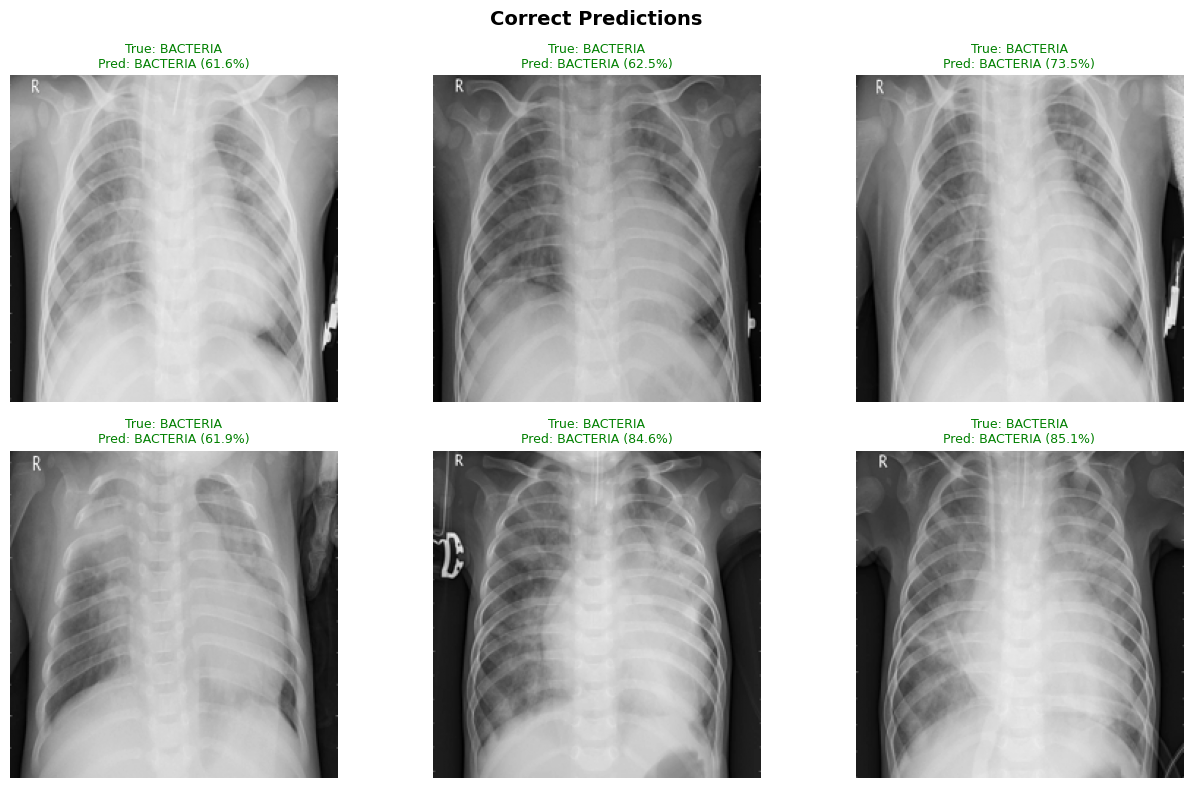

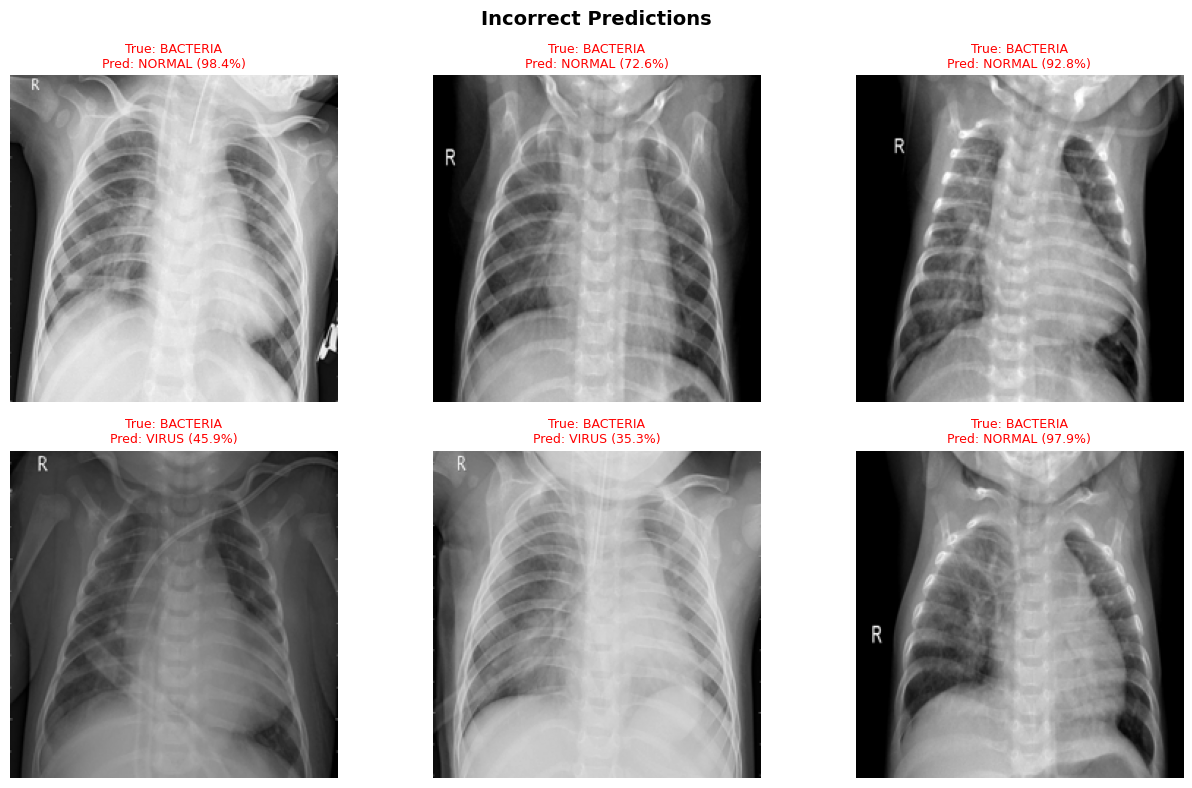

In [25]:
test_paths    = test_generator.filepaths
correct_idx   = np.where(y_pred == y_true)[0]
incorrect_idx = np.where(y_pred != y_true)[0]


def show_predictions(indices, title, n=6):
    indices = indices[:n]
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for ax, idx in zip(axes.flat, indices):
        img       = Image.open(test_paths[idx]).resize(IMG_SIZE)
        true_lbl  = CLASS_NAMES[y_true[idx]]
        pred_lbl  = CLASS_NAMES[y_pred[idx]]
        conf      = y_pred_probs[idx][y_pred[idx]] * 100
        color     = 'green' if y_pred[idx] == y_true[idx] else 'red'

        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({conf:.1f}%)',
                     color=color, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    safe_name = title[:15].replace(' ', '_').replace('/', '').replace('\\', '')
    plt.savefig(f'{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


show_predictions(correct_idx,   'Correct Predictions')
show_predictions(incorrect_idx, 'Incorrect Predictions')

---
## Step 10: Save the Model

In [37]:
model.save('chest_xray_cnn_model.h5')
print('Model saved as chest_xray_cnn_model.h5')
print('To load later: model = tf.keras.models.load_model("chest_xray_cnn_model.h5")')

Model saved as chest_xray_cnn_model.h5
To load later: model = tf.keras.models.load_model("chest_xray_cnn_model.h5")


---
## Step 11: Final Summary and Analysis

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average='weighted') * 100
recall    = recall_score(y_true, y_pred, average='weighted') * 100
f1        = f1_score(y_true, y_pred, average='weighted') * 100

print('=' * 55)
print('        FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 55)
print(f'  Test Accuracy : {test_accuracy*100:.2f}%')
print(f'  Precision     : {precision:.2f}%')
print(f'  Recall        : {recall:.2f}%')
print(f'  F1-Score      : {f1:.2f}%')
print('=' * 55)

        FINAL MODEL PERFORMANCE SUMMARY
  Test Accuracy : 84.94%
  Precision     : 85.60%
  Recall        : 84.94%
  F1-Score      : 84.26%


---
###
1. **BACTERIA vs VIRUS**:
   Both show similar hazy/cloudy patterns in chest X-rays.
   Confusing them is expected, even for medical professionals.

2. **CLASS IMBALANCE**:
   Pneumonia images outnumber Normal images in the dataset.
   We handled this with class weights and data augmentation.
   Without this fix, the model would just predict pneumonia always.

3. **DATA AUGMENTATION**:
   Augmentation gave the model more variety during training
   (rotated, flipped, zoomed images), making it more robust.

4. **MODEL LIMITATIONS**:
   - This is a screening tool, NOT a replacement for doctors.
   - Trained only on pediatric patients aged 1-5.
   - Real clinical use requires regulatory approval and more validation.
